
# Part B — 10c Final Model Comparison

## Goal

Run one clean final comparison using the **best feature set found so far**:

> **Base features + JAS NAO**

We compare only four methods:

1. Historical climatology
2. Rolling 10-season climatology
3. ElasticNet + NAO
4. CatBoost + NAO

The purpose is to answer one question:

> **Does the current ML feature set provide meaningful out-of-sample skill beyond climatology?**

We use the same expanding-window walk-forward framework as before.

## Why this notebook is intentionally small

Earlier experiments showed:

- the original feature set did not beat climatology,
- AO, PNA, and PDO did not materially help,
- NAO produced the best incremental improvement,
- the remaining question is whether a nonlinear model such as CatBoost can use the same feature set more effectively.

This is a final model comparison, not another broad feature search.


In [1]:

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print(
        "CatBoost is not installed. Install it with:\n"
        "pip install catboost\n"
        "or\n"
        "conda install -c conda-forge catboost"
    )

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

for directory in [PROCESSED_DIR, FIGURES_DIR, MODELS_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)


CatBoost is not installed. Install it with:
pip install catboost
or
conda install -c conda-forge catboost
Project root: /Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis


## 1. Load enhanced modeling data

In [2]:

DATA_PATH = PROCESSED_DIR / "forecast_modeling_dataset_enhanced.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "forecast_modeling_dataset_enhanced.csv was not found. "
        "Run 10b_forecast_feature_improvement.ipynb first."
    )

df = pd.read_csv(DATA_PATH)
df = df.sort_values("season_year").reset_index(drop=True)

print("Rows:", len(df))
print("Season range:", df["season_year"].min(), "→", df["season_year"].max())
display(df.head())


Rows: 70
Season range: 1951 → 2026


,season_year,snowfall_cm,valid_days,missing_days,measurable_snow_days,expected_days,coverage_pct,usable_90pct,full_calendar_window,usable,winter_coverage_pct,usable_strict,snowfall_clean_cm,snow_lag1_cm,snow_roll5_mean_cm,snow_roll10_mean_cm,snow_roll10_std_cm,previous_season_usable,oni_jas,oni_phase_threshold,sep_oct_mean_temp_c,sep_oct_total_precip_mm,sep_oct_temp_coverage_pct,sep_oct_precip_coverage_pct,autumn_features_usable,year_index,ao_jas,ao_jas_valid_months,nao_jas,nao_jas_valid_months,pna_jas,pna_jas_valid_months,pdo_jas,pdo_jas_valid_months
0,1951,111.8,365,0,40,365,100.0,True,True,True,100.0,True,111.8,196.4,136.22,141.04,35.388077,True,-0.57,cool_threshold,12.640984,100.0,100.0,100.0,True,12.0,-0.431833,3,-0.353333,3,-0.253333,3,-2.137000,3
1,1952,184.8,366,0,43,366,100.0,True,True,True,100.0,True,184.8,111.8,140.68,135.82,35.474836,True,0.90,warm_threshold,12.634426,102.3,100.0,100.0,True,13.0,-0.368400,3,-0.070000,3,-0.006667,3,-0.171000,3
2,1953,53.9,365,0,23,365,100.0,True,True,True,100.0,True,53.9,184.8,148.28,144.61,35.649231,True,-0.20,neutral_threshold,11.896721,77.4,100.0,100.0,True,14.0,-0.010233,3,-0.303333,3,0.033333,3,-0.947000,3
3,1954,124.7,365,0,38,365,100.0,True,True,True,100.0,True,124.7,53.9,134.68,131.76,42.929922,True,0.68,warm_threshold,13.195082,92.5,100.0,100.0,True,15.0,0.359933,3,-0.220000,3,-0.166667,3,-0.280333,3
4,1955,109.3,365,0,44,365,100.0,True,True,True,100.0,True,109.3,124.7,134.32,131.86,42.910222,True,-0.83,cool_threshold,13.193443,294.6,100.0,100.0,True,16.0,0.173333,3,-0.980000,3,0.073333,3,-0.170667,3


## 2. Final feature set

In [3]:

FINAL_FEATURES = [
    "oni_jas",
    "nao_jas",
    "sep_oct_mean_temp_c",
    "sep_oct_total_precip_mm",
    "snow_lag1_cm",
    "snow_roll5_mean_cm",
    "snow_roll10_mean_cm",
    "snow_roll10_std_cm",
    "year_index",
]

required_cols = [
    "season_year",
    "snowfall_cm",
] + FINAL_FEATURES

model_data = (
    df.dropna(subset=required_cols)
      .sort_values("season_year")
      .reset_index(drop=True)
)

print("Final model-ready rows:", len(model_data))
print(
    "Final season range:",
    model_data["season_year"].min(),
    "→",
    model_data["season_year"].max()
)

assert model_data["season_year"].is_monotonic_increasing
assert model_data["season_year"].is_unique
assert model_data[required_cols].notna().all().all()

display(
    model_data[
        ["season_year", "snowfall_cm"] + FINAL_FEATURES
    ].head(10)
)


Final model-ready rows: 70
Final season range: 1951 → 2026


,season_year,snowfall_cm,oni_jas,nao_jas,sep_oct_mean_temp_c,sep_oct_total_precip_mm,snow_lag1_cm,snow_roll5_mean_cm,snow_roll10_mean_cm,snow_roll10_std_cm,year_index
0,1951,111.8,-0.57,-0.353333,12.640984,100.0,196.4,136.22,141.04,35.388077,12.0
1,1952,184.8,0.90,-0.070000,12.634426,102.3,111.8,140.68,135.82,35.474836,13.0
2,1953,53.9,-0.20,-0.303333,11.896721,77.4,184.8,148.28,144.61,35.649231,14.0
3,1954,124.7,0.68,-0.220000,13.195082,92.5,53.9,134.68,131.76,42.929922,15.0
4,1955,109.3,-0.83,-0.980000,13.193443,294.6,124.7,134.32,131.86,42.910222,16.0
5,1956,160.0,-0.92,1.050000,13.373770,107.9,109.3,116.90,126.56,41.996090,17.0
6,1957,117.3,-0.52,-0.626667,11.755738,63.0,160.0,126.54,133.61,40.988900,18.0
7,1958,96.1,1.03,-1.133333,12.334426,141.5,117.3,113.04,130.66,40.995696,19.0
8,1959,146.5,0.32,-1.120000,13.072131,110.0,96.1,121.48,128.08,42.396169,20.0
9,1960,141.5,-0.23,0.560000,14.129508,148.8,146.5,125.84,130.08,42.783325,21.0



## 3. Walk-forward setup

Use the first 20 model-ready winters as the minimum training history.

Each later winter is predicted once using only earlier data.


In [4]:

MIN_TRAIN_SIZE = 20

if len(model_data) <= MIN_TRAIN_SIZE:
    raise ValueError(
        f"Need more than {MIN_TRAIN_SIZE} rows; found {len(model_data)}."
    )

FIRST_TEST_SEASON = int(
    model_data.iloc[MIN_TRAIN_SIZE]["season_year"]
)
LAST_TEST_SEASON = int(
    model_data.iloc[-1]["season_year"]
)

print("Minimum training observations:", MIN_TRAIN_SIZE)
print("First test season:", FIRST_TEST_SEASON)
print("Last test season:", LAST_TEST_SEASON)
print("Out-of-sample winters:", len(model_data) - MIN_TRAIN_SIZE)


Minimum training observations: 20
First test season: 1971
Last test season: 2026
Out-of-sample winters: 50


## 4. Model definitions

In [5]:

def make_elasticnet(n_train):
    n_splits = min(
        5,
        max(2, n_train // 6)
    )

    return Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            ElasticNetCV(
                l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
                alphas=np.logspace(-3, 2, 60),
                cv=TimeSeriesSplit(n_splits=n_splits),
                max_iter=20000,
            )
        ),
    ])


def make_catboost():
    if not CATBOOST_AVAILABLE:
        return None

    # Conservative configuration because the sample is small.
    return CatBoostRegressor(
        iterations=350,
        depth=3,
        learning_rate=0.03,
        loss_function="RMSE",
        l2_leaf_reg=8,
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
    )


def rmse(actual, predicted):
    return np.sqrt(
        mean_squared_error(actual, predicted)
    )



CatBoost is deliberately **not heavily tuned** here.

If a fixed conservative CatBoost cannot show stable skill, aggressive hyperparameter search on ~70 winters would create a high overfitting risk.


## 5. Final walk-forward comparison

In [6]:

records = []

for test_idx in range(MIN_TRAIN_SIZE, len(model_data)):
    train = model_data.iloc[:test_idx].copy()
    test = model_data.iloc[[test_idx]].copy()

    X_train = train[FINAL_FEATURES]
    y_train = train["snowfall_cm"]
    X_test = test[FINAL_FEATURES]

    season_year = int(test["season_year"].iloc[0])
    actual = float(test["snowfall_cm"].iloc[0])

    # 1) Historical climatology
    pred_clim = float(y_train.mean())

    records.append({
        "season_year": season_year,
        "model": "Historical Climatology",
        "actual_cm": actual,
        "predicted_cm": pred_clim,
        "train_n": len(train),
    })

    # 2) Rolling 10-season climatology
    pred_roll10 = float(y_train.tail(10).mean())

    records.append({
        "season_year": season_year,
        "model": "Rolling 10-Season Mean",
        "actual_cm": actual,
        "predicted_cm": pred_roll10,
        "train_n": len(train),
    })

    # 3) ElasticNet + NAO
    elastic = make_elasticnet(len(train))
    elastic.fit(X_train, y_train)

    pred_elastic = float(
        elastic.predict(X_test)[0]
    )

    records.append({
        "season_year": season_year,
        "model": "ElasticNet + NAO",
        "actual_cm": actual,
        "predicted_cm": pred_elastic,
        "train_n": len(train),
    })

    # 4) CatBoost + NAO
    if CATBOOST_AVAILABLE:
        cat = make_catboost()
        cat.fit(X_train, y_train)

        pred_cat = float(
            cat.predict(X_test)[0]
        )

        records.append({
            "season_year": season_year,
            "model": "CatBoost + NAO",
            "actual_cm": actual,
            "predicted_cm": pred_cat,
            "train_n": len(train),
        })

predictions = pd.DataFrame(records)

predictions["error_cm"] = (
    predictions["predicted_cm"]
    - predictions["actual_cm"]
)

predictions["abs_error_cm"] = (
    predictions["error_cm"].abs()
)

predictions["squared_error"] = (
    predictions["error_cm"] ** 2
)

print("Prediction rows:", len(predictions))
display(predictions.head(12))


Prediction rows: 150


,season_year,model,actual_cm,predicted_cm,train_n,error_cm,abs_error_cm,squared_error
0,1971,Historical Climatology,171.7,130.045000,20,-41.655000,41.655000,1735.139025
1,1971,Rolling 10-Season Mean,171.7,135.500000,20,-36.200000,36.200000,1310.440000
2,1971,ElasticNet + NAO,171.7,129.632276,20,-42.067724,42.067724,1769.693389
3,1972,Historical Climatology,188.9,132.028571,21,-56.871429,56.871429,3234.359388
4,1972,Rolling 10-Season Mean,188.9,140.320000,21,-48.580000,48.580000,2360.016400
5,1972,ElasticNet + NAO,188.9,133.849630,21,-55.050370,55.050370,3030.543209
6,1973,Historical Climatology,110.0,134.613636,22,24.613636,24.613636,605.831095
7,1973,Rolling 10-Season Mean,110.0,145.720000,22,35.720000,35.720000,1275.918400
8,1973,ElasticNet + NAO,110.0,136.968094,22,26.968094,26.968094,727.278089
9,1974,Historical Climatology,127.8,133.543478,23,5.743478,5.743478,32.987543


## 6. Full-period model comparison

In [7]:

comparison = (
    predictions
    .groupby("model")
    .apply(
        lambda g: pd.Series({
            "n_forecasts": len(g),
            "MAE_cm": mean_absolute_error(
                g["actual_cm"],
                g["predicted_cm"]
            ),
            "RMSE_cm": rmse(
                g["actual_cm"],
                g["predicted_cm"]
            ),
            "Bias_cm": g["error_cm"].mean(),
        }),
        include_groups=False
    )
    .reset_index()
)

climatology_mae = float(
    comparison.loc[
        comparison["model"] == "Historical Climatology",
        "MAE_cm"
    ].iloc[0]
)

climatology_rmse = float(
    comparison.loc[
        comparison["model"] == "Historical Climatology",
        "RMSE_cm"
    ].iloc[0]
)

comparison["MAE_skill_vs_climatology_pct"] = (
    1 - comparison["MAE_cm"] / climatology_mae
) * 100

comparison["RMSE_skill_vs_climatology_pct"] = (
    1 - comparison["RMSE_cm"] / climatology_rmse
) * 100

comparison = comparison.sort_values(
    ["MAE_cm", "RMSE_cm"]
).reset_index(drop=True)

display(
    comparison.style.format({
        "n_forecasts": "{:.0f}",
        "MAE_cm": "{:.2f}",
        "RMSE_cm": "{:.2f}",
        "Bias_cm": "{:+.2f}",
        "MAE_skill_vs_climatology_pct": "{:+.1f}%",
        "RMSE_skill_vs_climatology_pct": "{:+.1f}%"
    })
)


,model,n_forecasts,MAE_cm,RMSE_cm,Bias_cm,MAE_skill_vs_climatology_pct,RMSE_skill_vs_climatology_pct
0,ElasticNet + NAO,50,31.30,38.05,+8.82,+0.8%,-0.5%
1,Historical Climatology,50,31.56,37.87,+9.92,+0.0%,+0.0%
2,Rolling 10-Season Mean,50,31.68,37.72,+0.64,-0.4%,+0.4%


## 7. Recent 15-winter performance

In [8]:

test_years = sorted(
    predictions["season_year"].unique()
)

recent_years = test_years[-15:]

recent = predictions[
    predictions["season_year"].isin(recent_years)
].copy()

recent_comparison = (
    recent
    .groupby("model")
    .apply(
        lambda g: pd.Series({
            "n_forecasts": len(g),
            "MAE_cm": mean_absolute_error(
                g["actual_cm"],
                g["predicted_cm"]
            ),
            "RMSE_cm": rmse(
                g["actual_cm"],
                g["predicted_cm"]
            ),
            "Bias_cm": g["error_cm"].mean(),
        }),
        include_groups=False
    )
    .reset_index()
    .sort_values("MAE_cm")
)

display(
    recent_comparison.style.format({
        "n_forecasts": "{:.0f}",
        "MAE_cm": "{:.2f}",
        "RMSE_cm": "{:.2f}",
        "Bias_cm": "{:+.2f}",
    })
)


,model,n_forecasts,MAE_cm,RMSE_cm,Bias_cm
0,ElasticNet + NAO,15,33.22,40.69,+4.52
1,Historical Climatology,15,34.71,41.83,+9.07
2,Rolling 10-Season Mean,15,36.46,43.16,-2.80


## 8. Stability across early vs recent test periods

In [9]:

test_years = sorted(
    predictions["season_year"].unique()
)

midpoint = len(test_years) // 2

early_years = test_years[:midpoint]
late_years = test_years[midpoint:]

period_rows = []

for period_name, years in {
    "Earlier half": early_years,
    "Later half": late_years,
}.items():

    d = predictions[
        predictions["season_year"].isin(years)
    ]

    for model_name, g in d.groupby("model"):
        period_rows.append({
            "period": period_name,
            "model": model_name,
            "n": len(g),
            "MAE_cm": mean_absolute_error(
                g["actual_cm"],
                g["predicted_cm"]
            ),
            "RMSE_cm": rmse(
                g["actual_cm"],
                g["predicted_cm"]
            ),
            "Bias_cm": g["error_cm"].mean(),
        })

period_comparison = pd.DataFrame(period_rows)

display(
    period_comparison.sort_values(
        ["period", "MAE_cm"]
    ).style.format({
        "MAE_cm": "{:.2f}",
        "RMSE_cm": "{:.2f}",
        "Bias_cm": "{:+.2f}",
    })
)


,period,model,n,MAE_cm,RMSE_cm,Bias_cm
2,Earlier half,Rolling 10-Season Mean,25,26.72,31.65,+6.48
1,Earlier half,Historical Climatology,25,28.72,34.19,+12.51
0,Earlier half,ElasticNet + NAO,25,28.85,35.17,+13.33
3,Later half,ElasticNet + NAO,25,33.76,40.73,+4.31
4,Later half,Historical Climatology,25,34.40,41.24,+7.34
5,Later half,Rolling 10-Season Mean,25,36.64,42.94,-5.20


## 9. Extreme-winter diagnostics


The biggest weakness in earlier models was regression toward normal snowfall.

We explicitly inspect the lowest-snow and highest-snow test winters.


In [10]:

actual_test = (
    predictions[
        predictions["model"] == "Historical Climatology"
    ][["season_year", "actual_cm"]]
    .drop_duplicates("season_year")
)

LOW_Q = actual_test["actual_cm"].quantile(0.20)
HIGH_Q = actual_test["actual_cm"].quantile(0.80)

print(f"Low-snow threshold (20th percentile): {LOW_Q:.1f} cm")
print(f"High-snow threshold (80th percentile): {HIGH_Q:.1f} cm")

predictions["winter_type"] = np.select(
    [
        predictions["actual_cm"] <= LOW_Q,
        predictions["actual_cm"] >= HIGH_Q,
    ],
    [
        "Low-snow",
        "High-snow",
    ],
    default="Middle"
)

extreme_comparison = (
    predictions[
        predictions["winter_type"].isin(
            ["Low-snow", "High-snow"]
        )
    ]
    .groupby(["winter_type", "model"])
    .apply(
        lambda g: pd.Series({
            "n": len(g),
            "MAE_cm": mean_absolute_error(
                g["actual_cm"],
                g["predicted_cm"]
            ),
            "Bias_cm": g["error_cm"].mean(),
        }),
        include_groups=False
    )
    .reset_index()
)

display(
    extreme_comparison.sort_values(
        ["winter_type", "MAE_cm"]
    ).style.format({
        "MAE_cm": "{:.2f}",
        "Bias_cm": "{:+.2f}",
    })
)


Low-snow threshold (20th percentile): 81.0 cm
High-snow threshold (80th percentile): 144.6 cm


,winter_type,model,n,MAE_cm,Bias_cm
0,High-snow,ElasticNet + NAO,10.000000,39.71,-39.71
1,High-snow,Historical Climatology,10.000000,40.15,-40.15
2,High-snow,Rolling 10-Season Mean,10.000000,46.99,-46.99
5,Low-snow,Rolling 10-Season Mean,10.000000,48.65,+48.65
3,Low-snow,ElasticNet + NAO,10.000000,57.55,+57.55
4,Low-snow,Historical Climatology,10.000000,57.77,+57.77


## 10. Largest forecast misses

In [11]:

for model_name in comparison["model"]:
    print("\n", "=" * 70)
    print(model_name)
    print("=" * 70)

    display(
        predictions[
            predictions["model"] == model_name
        ]
        .nlargest(8, "abs_error_cm")
        [
            [
                "season_year",
                "actual_cm",
                "predicted_cm",
                "error_cm",
                "abs_error_cm",
            ]
        ]
    )



ElasticNet + NAO


,season_year,actual_cm,predicted_cm,error_cm,abs_error_cm
116,2012,42.8,119.272549,76.472549,76.472549
104,2008,194.0,119.527814,-74.472186,74.472186
149,2026,190.6,116.407855,-74.192145,74.192145
110,2010,52.4,122.275000,69.875000,69.875000
29,1980,79.7,145.815011,66.115011,66.115011
38,1983,71.5,136.934698,65.434698,65.434698
101,2007,60.3,121.516981,61.216981,61.216981
56,1989,72.2,127.599623,55.399623,55.399623



Historical Climatology


,season_year,actual_cm,predicted_cm,error_cm,abs_error_cm
114,2012,42.8,121.182759,78.382759,78.382759
102,2008,194.0,120.383333,-73.616667,73.616667
147,2026,190.6,118.243478,-72.356522,72.356522
108,2010,52.4,122.275000,69.875000,69.875000
99,2007,60.3,121.516981,61.216981,61.216981
36,1983,71.5,130.437500,58.937500,58.937500
3,1972,188.9,132.028571,-56.871429,56.871429
54,1989,72.2,126.547368,54.347368,54.347368



Rolling 10-Season Mean


,season_year,actual_cm,predicted_cm,error_cm,abs_error_cm
103,2008,194.0,106.39,-87.61,87.61
148,2026,190.6,108.74,-81.86,81.86
115,2012,42.8,116.88,74.08,74.08
109,2010,52.4,120.69,68.29,68.29
28,1980,79.7,143.69,63.99,63.99
100,2007,60.3,114.80,54.50,54.50
31,1981,81.8,136.23,54.43,54.43
37,1983,71.5,121.25,49.75,49.75


## 11. Plot walk-forward forecasts

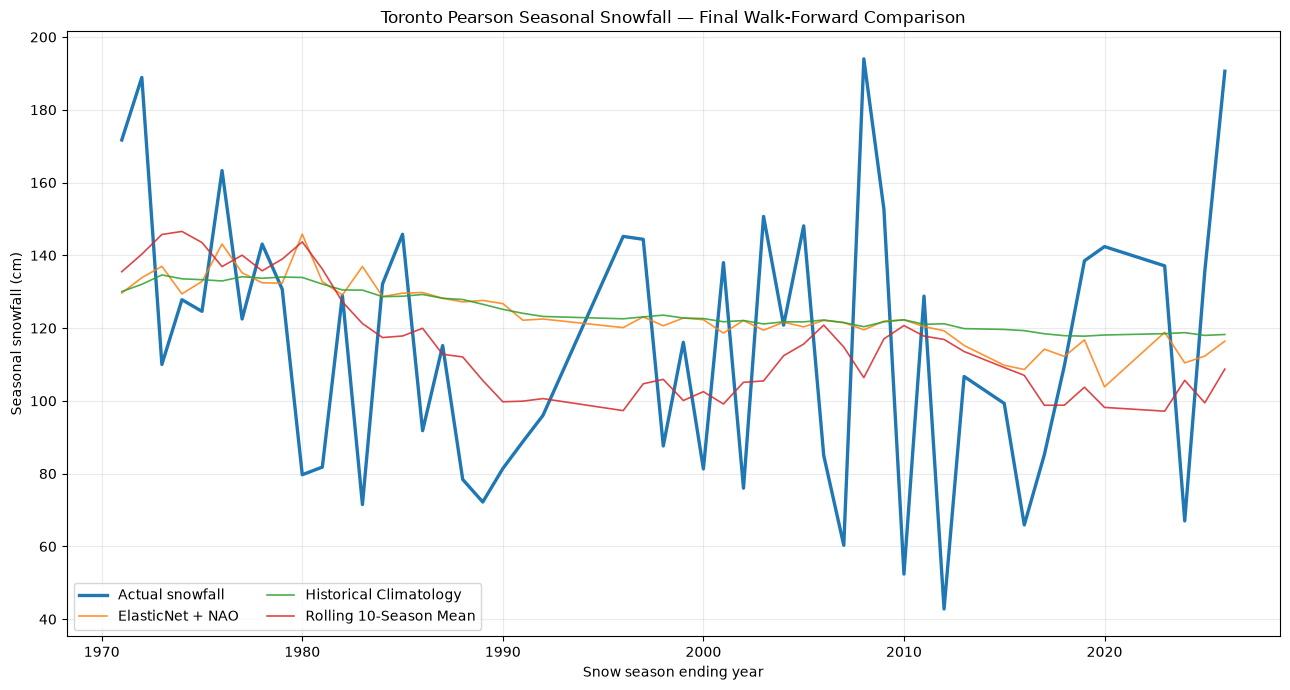

In [12]:

actual_series = (
    predictions[
        predictions["model"] == "Historical Climatology"
    ][["season_year", "actual_cm"]]
    .drop_duplicates("season_year")
)

fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(
    actual_series["season_year"],
    actual_series["actual_cm"],
    linewidth=2.4,
    label="Actual snowfall"
)

for model_name in comparison["model"]:
    g = predictions[
        predictions["model"] == model_name
    ]

    ax.plot(
        g["season_year"],
        g["predicted_cm"],
        linewidth=1.2,
        alpha=0.85,
        label=model_name
    )

ax.set_title(
    "Toronto Pearson Seasonal Snowfall — Final Walk-Forward Comparison"
)
ax.set_xlabel("Snow season ending year")
ax.set_ylabel("Seasonal snowfall (cm)")
ax.grid(alpha=0.25)
ax.legend(ncol=2)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "part_b_final_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 12. Plot MAE comparison

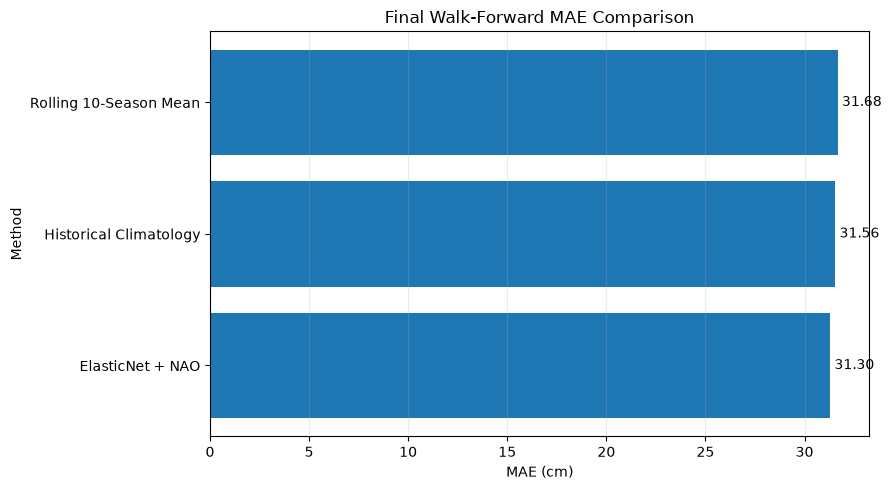

In [13]:

plot_comp = comparison.sort_values(
    "MAE_cm",
    ascending=True
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    plot_comp["model"],
    plot_comp["MAE_cm"]
)

ax.set_title(
    "Final Walk-Forward MAE Comparison"
)
ax.set_xlabel("MAE (cm)")
ax.set_ylabel("Method")
ax.grid(axis="x", alpha=0.25)

for i, value in enumerate(
    plot_comp["MAE_cm"]
):
    ax.text(
        value,
        i,
        f" {value:.2f}",
        va="center"
    )

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "part_b_final_model_mae.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



## 13. Practical decision rule

We do not want to call a model "better" because it beats climatology by a trivial fraction.

For this project, define a **practical skill threshold**:

- MAE improvement vs climatology ≥ **3%**
- RMSE improvement vs climatology ≥ **0%**

This is a project decision rule, not a universal scientific standard.

It simply prevents us from promoting a complex model based on a negligible MAE difference while worsening large errors.


In [14]:

decision_rows = comparison.copy()

decision_rows["passes_mae_threshold"] = (
    decision_rows["MAE_skill_vs_climatology_pct"] >= 3
)

decision_rows["passes_rmse_threshold"] = (
    decision_rows["RMSE_skill_vs_climatology_pct"] >= 0
)

decision_rows["passes_practical_skill_gate"] = (
    decision_rows["passes_mae_threshold"]
    & decision_rows["passes_rmse_threshold"]
)

display(
    decision_rows[
        [
            "model",
            "MAE_cm",
            "RMSE_cm",
            "MAE_skill_vs_climatology_pct",
            "RMSE_skill_vs_climatology_pct",
            "passes_practical_skill_gate",
        ]
    ].style.format({
        "MAE_cm": "{:.2f}",
        "RMSE_cm": "{:.2f}",
        "MAE_skill_vs_climatology_pct": "{:+.1f}%",
        "RMSE_skill_vs_climatology_pct": "{:+.1f}%",
    })
)


,model,MAE_cm,RMSE_cm,MAE_skill_vs_climatology_pct,RMSE_skill_vs_climatology_pct,passes_practical_skill_gate
0,ElasticNet + NAO,31.30,38.05,+0.8%,-0.5%,False
1,Historical Climatology,31.56,37.87,+0.0%,+0.0%,False
2,Rolling 10-Season Mean,31.68,37.72,-0.4%,+0.4%,False


## 14. Select production candidate conservatively

In [15]:

eligible = decision_rows[
    decision_rows["passes_practical_skill_gate"]
].copy()

if len(eligible):
    selected = (
        eligible.sort_values(
            ["MAE_cm", "RMSE_cm"]
        )
        .iloc[0]
    )

    PRODUCTION_CANDIDATE = selected["model"]
    DECISION = "ML/model candidate passes practical skill gate"

else:
    PRODUCTION_CANDIDATE = "Historical Climatology"
    DECISION = (
        "No complex model passes the practical skill gate; "
        "retain climatology as the benchmark production method"
    )

print("Decision:", DECISION)
print("Production candidate:", PRODUCTION_CANDIDATE)


Decision: No complex model passes the practical skill gate; retain climatology as the benchmark production method
Production candidate: Historical Climatology



This conservative selection rule is important.

If climatology remains the production candidate, that is a valid result:

> the current predictors do not yet support a sufficiently skillful seasonal snowfall point forecast.

We can still continue the project by building a **probabilistic climatology / probabilistic forecast framework** and by improving predictors later.


## 15. Fit selected candidate on all available data

In [16]:

X = model_data[FINAL_FEATURES]
y = model_data["snowfall_cm"]

fitted_model = None
metadata = {
    "selected_model": PRODUCTION_CANDIDATE,
    "decision": DECISION,
    "features": FINAL_FEATURES,
    "training_start_season": int(model_data["season_year"].min()),
    "training_end_season": int(model_data["season_year"].max()),
    "n_training_rows": int(len(model_data)),
    "practical_skill_gate": {
        "minimum_mae_skill_pct": 3.0,
        "minimum_rmse_skill_pct": 0.0,
    }
}

if PRODUCTION_CANDIDATE == "ElasticNet + NAO":
    fitted_model = make_elasticnet(len(model_data))
    fitted_model.fit(X, y)

elif PRODUCTION_CANDIDATE == "CatBoost + NAO":
    if not CATBOOST_AVAILABLE:
        raise RuntimeError(
            "CatBoost was selected but is not installed."
        )

    fitted_model = make_catboost()
    fitted_model.fit(X, y)

elif PRODUCTION_CANDIDATE == "Rolling 10-Season Mean":
    metadata["forecast_value_cm"] = float(
        y.tail(10).mean()
    )

elif PRODUCTION_CANDIDATE == "Historical Climatology":
    metadata["forecast_value_cm"] = float(
        y.mean()
    )

else:
    raise ValueError(
        f"Unexpected production candidate: {PRODUCTION_CANDIDATE}"
    )

print("Fitted/registered candidate:", PRODUCTION_CANDIDATE)


Fitted/registered candidate: Historical Climatology


## 16. Save final comparison outputs

In [17]:

PREDICTIONS_PATH = (
    PROCESSED_DIR
    / "final_walk_forward_predictions.csv"
)

COMPARISON_PATH = (
    PROCESSED_DIR
    / "final_model_comparison.csv"
)

FINAL_DATA_PATH = (
    PROCESSED_DIR
    / "final_model_dataset.csv"
)

METADATA_PATH = (
    MODELS_DIR
    / "final_snowfall_model_metadata.json"
)

MODEL_PATH = (
    MODELS_DIR
    / "final_snowfall_model.joblib"
)

predictions.to_csv(
    PREDICTIONS_PATH,
    index=False
)

comparison.to_csv(
    COMPARISON_PATH,
    index=False
)

model_data.to_csv(
    FINAL_DATA_PATH,
    index=False
)

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=2
    )

if fitted_model is not None:
    joblib.dump(
        fitted_model,
        MODEL_PATH
    )
    print("Saved model:", MODEL_PATH)

print("Saved predictions:", PREDICTIONS_PATH)
print("Saved comparison:", COMPARISON_PATH)
print("Saved final dataset:", FINAL_DATA_PATH)
print("Saved metadata:", METADATA_PATH)


Saved predictions: /Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed/final_walk_forward_predictions.csv
Saved comparison: /Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed/final_model_comparison.csv
Saved final dataset: /Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed/final_model_dataset.csv
Saved metadata: /Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/models/final_snowfall_model_metadata.json


## 17. Generate final point-forecast report

In [18]:

report = [
    "# Toronto Seasonal Snowfall — Final Point-Forecast Model Comparison",
    "",
    f"- Model-ready winters: {len(model_data)}",
    f"- Evaluation range: {FIRST_TEST_SEASON}–{LAST_TEST_SEASON}",
    f"- Out-of-sample forecasts per available method: {len(model_data) - MIN_TRAIN_SIZE}",
    "",
    "## Results",
    "",
]

for _, row in comparison.iterrows():
    report.append(
        f"- {row['model']}: "
        f"MAE={row['MAE_cm']:.2f} cm, "
        f"RMSE={row['RMSE_cm']:.2f} cm, "
        f"bias={row['Bias_cm']:+.2f} cm, "
        f"MAE skill={row['MAE_skill_vs_climatology_pct']:+.1f}%, "
        f"RMSE skill={row['RMSE_skill_vs_climatology_pct']:+.1f}%"
    )

report.extend([
    "",
    "## Decision",
    "",
    f"**Production candidate: {PRODUCTION_CANDIDATE}**",
    "",
    DECISION,
    "",
    "The next stage should convert the selected benchmark/candidate into "
    "a probabilistic forecast rather than presenting a single snowfall total "
    "as certain.",
])

REPORT_PATH = (
    REPORTS_DIR
    / "part_b_final_model_comparison.md"
)

REPORT_PATH.write_text(
    "\n".join(report),
    encoding="utf-8"
)

print(REPORT_PATH.read_text())


# Toronto Seasonal Snowfall — Final Point-Forecast Model Comparison

- Model-ready winters: 70
- Evaluation range: 1971–2026
- Out-of-sample forecasts per available method: 50

## Results

- ElasticNet + NAO: MAE=31.30 cm, RMSE=38.05 cm, bias=+8.82 cm, MAE skill=+0.8%, RMSE skill=-0.5%
- Historical Climatology: MAE=31.56 cm, RMSE=37.87 cm, bias=+9.92 cm, MAE skill=+0.0%, RMSE skill=+0.0%
- Rolling 10-Season Mean: MAE=31.68 cm, RMSE=37.72 cm, bias=+0.64 cm, MAE skill=-0.4%, RMSE skill=+0.4%

## Decision

**Production candidate: Historical Climatology**

No complex model passes the practical skill gate; retain climatology as the benchmark production method

The next stage should convert the selected benchmark/candidate into a probabilistic forecast rather than presenting a single snowfall total as certain.



# Next decision

After running this notebook, send:

1. the **full comparison table**,
2. the **recent 15-winter table**,
3. the **extreme-winter diagnostics**,
4. the final **Production candidate**.

Then we decide whether to move directly to:

## `11_probabilistic_snowfall_forecast.ipynb`

or whether the current point-forecast model is still too weak and should remain a climatology-based probabilistic system while we improve predictors.
